# Порівняльний аналіз покадрових та послідовних моделей для класифікації відеоданих

## Експерименти на наборі даних UCF101

У ноутбуці реалізовано підготовку даних, навчання та оцінювання моделей
CNN + Mean Pooling і CNN-LSTM на наборі даних UCF101.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import importlib
import main_models
importlib.reload(main_models)

from main_models import *
load_env()

path = get_dataset_path(
    "UCF101_DATASET_PATH",
    "matthewjansen/ucf101-action-recognition"
)

DATASET_ROOT = Path(path)
OUTPUT_ROOT = DATASET_ROOT / "processed_frames"
NUM_FRAMES = int(os.getenv("NUM_FRAMES", 8))
IMG_SIZE = int(os.getenv("IMG_SIZE", 112))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", 4))
EPOCHS = int(os.getenv("EPOCHS", 10))
LR = float(os.getenv("LR", 1e-4))
SPLITS = ["train", "val", "test"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SELECTED_CLASSES = [
    "Archery",
    "Basketball",
    "Biking",
    "BreastStroke",
    "BenchPress",
    "Swing",
    "TennisSwing",
    "BrushingTeeth"
]

### 1. Дослідження структури набору даних

In [4]:
print("Path to dataset files:", DATASET_ROOT)
print(os.listdir(path))
print(os.listdir(path + "/train")[:20])
print(os.listdir(path + "/train/Swing")[:20])

Path to dataset files: C:\Users\Sofiya\.cache\kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4
['processed_frames', 'test', 'test.csv', 'train', 'train.csv', 'val', 'val.csv']
['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling', 'BoxingPunchingBag', 'BoxingSpeedBag', 'BreastStroke', 'BrushingTeeth']
['v_Swing_g01_c03.avi', 'v_Swing_g01_c04.avi', 'v_Swing_g01_c05.avi', 'v_Swing_g02_c01.avi', 'v_Swing_g02_c02.avi', 'v_Swing_g02_c03.avi', 'v_Swing_g02_c04.avi', 'v_Swing_g03_c03.avi', 'v_Swing_g03_c04.avi', 'v_Swing_g04_c01.avi', 'v_Swing_g04_c02.avi', 'v_Swing_g04_c06.avi', 'v_Swing_g04_c07.avi', 'v_Swing_g05_c01.avi', 'v_Swing_g05_c02.avi', 'v_Swing_g05_c03.avi', 'v_Swing_g05_c04.avi', 'v_Swing_g05_c06.avi', 'v_Swing_g05_c07.avi', 'v_Swing_g06_c01.avi']


In [3]:
import cv2
import glob
import os

sample_video = glob.glob(os.path.join(path, "train", "*", "*.avi"))[0]
print("Video:", sample_video)

cap = cv2.VideoCapture(sample_video)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

print("Frames:", frame_count)
print("FPS:", fps)
print("Duration (sec):", frame_count / fps if fps > 0 else "Unknown")


Video: C:\Users\Sofiya\.cache\kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4\train\ApplyEyeMakeup\v_ApplyEyeMakeup_g01_c01.avi
Frames: 164
FPS: 25.0
Duration (sec): 6.56


In [ ]:
class_name = "Biking"

videos = glob.glob(os.path.join(path, "train", class_name, "*.avi"))
print("Videos in class:", len(videos))

sample_video = videos[43]
print("Selected:", sample_video)


Videos in class: 100
Selected: C:\Users\Sofiya\.cache\kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4\train\Biking\v_Biking_g11_c04.avi


### 2. Виділення кадрів з відео в окрему папку

In [ ]:
def process_split(split: str):
    return process_ucf_split(
        split=split,
        dataset_root=DATASET_ROOT,
        output_root=OUTPUT_ROOT,
        selected_classes=SELECTED_CLASSES,
        num_frames=NUM_FRAMES,
        img_size=IMG_SIZE,
    )

'''
for split in SPLITS:
    process_split(split)

print("\nГотово. Кадри збережені в:", OUTPUT_ROOT)
'''

train: 921 відео після фільтрації


Processing train: 100%|██████████| 921/921 [00:43<00:00, 20.94it/s]


val: 154 відео після фільтрації


Processing val: 100%|██████████| 154/154 [00:07<00:00, 19.74it/s]


test: 158 відео після фільтрації


Processing test: 100%|██████████| 158/158 [00:07<00:00, 20.28it/s]


Готово. Кадри збережені в: C:\Users\Sofiya\.cache\kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4\processed_frames


### 3. Завантаження даних і формування вибірок для навчання, валідації та тестування

In [ ]:
train_df = pd.read_csv(DATASET_ROOT / "train.csv")
val_df   = pd.read_csv(DATASET_ROOT / "val.csv")
test_df  = pd.read_csv(DATASET_ROOT / "test.csv")

train_df = train_df[train_df["label"].isin(SELECTED_CLASSES)].reset_index(drop=True)
val_df   = val_df[val_df["label"].isin(SELECTED_CLASSES)].reset_index(drop=True)
test_df  = test_df[test_df["label"].isin(SELECTED_CLASSES)].reset_index(drop=True)

print(train_df.head())
print(train_df.columns)

         clip_name                         clip_path  label
0  v_Swing_g05_c02  /train/Swing/v_Swing_g05_c02.avi  Swing
1  v_Swing_g21_c03  /train/Swing/v_Swing_g21_c03.avi  Swing
2  v_Swing_g07_c01  /train/Swing/v_Swing_g07_c01.avi  Swing
3  v_Swing_g24_c04  /train/Swing/v_Swing_g24_c04.avi  Swing
4  v_Swing_g20_c03  /train/Swing/v_Swing_g20_c03.avi  Swing
Index(['clip_name', 'clip_path', 'label'], dtype='str')


In [66]:
frames_train_root = DATASET_ROOT / "processed_frames" / "train"
frames_val_root   = DATASET_ROOT / "processed_frames" / "val"
frames_test_root  = DATASET_ROOT / "processed_frames" / "test"

classes = sorted(train_df["label"].astype(str).unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

train_dataset = VideoFramesDataset(
    dataframe=train_df,
    frames_root=frames_train_root,
    num_frames=NUM_FRAMES,
    transform=ClipTrainTransform(size=IMG_SIZE),
    class_to_idx=class_to_idx
)

val_dataset = VideoFramesDataset(
    dataframe=val_df,
    frames_root=frames_val_root,
    num_frames=NUM_FRAMES,
    transform=ClipEvalTransform(size=IMG_SIZE),
    class_to_idx=class_to_idx
)

test_dataset = VideoFramesDataset(
    dataframe=test_df,
    frames_root=frames_test_root,
    num_frames=NUM_FRAMES,
    transform=ClipEvalTransform(size=IMG_SIZE),
    class_to_idx=class_to_idx
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

### 4. Створення та навчання моделі CNN+mean pooling. Оцінка моделі.

In [ ]:
model = CNNMeanPoolingClassifier(num_classes=len(class_to_idx), lr=LR)
model.fit(train_loader, val_loader, epochs=EPOCHS)

test_acc = model.evaluate(test_loader)
print("Test accuracy:", test_acc)

preds = model.predict(test_loader)
print(preds[:10])

Epoch 1/10 | Train loss: 1.1778 | Train acc: 0.6091
Epoch 1/10 | Val acc: 0.8052
Epoch 2/10 | Train loss: 0.7858 | Train acc: 0.7329
Epoch 2/10 | Val acc: 0.9091
Epoch 3/10 | Train loss: 0.6730 | Train acc: 0.7666
Epoch 3/10 | Val acc: 0.9416
Epoch 4/10 | Train loss: 0.6104 | Train acc: 0.7970
Epoch 4/10 | Val acc: 0.9026
Epoch 5/10 | Train loss: 0.5779 | Train acc: 0.8111
Epoch 5/10 | Val acc: 0.9481
Epoch 6/10 | Train loss: 0.4852 | Train acc: 0.8469
Epoch 6/10 | Val acc: 0.9870
Epoch 7/10 | Train loss: 0.5009 | Train acc: 0.8415
Epoch 7/10 | Val acc: 0.9221
Epoch 8/10 | Train loss: 0.4596 | Train acc: 0.8632
Epoch 8/10 | Val acc: 0.9740
Epoch 9/10 | Train loss: 0.3895 | Train acc: 0.8838
Epoch 9/10 | Val acc: 0.9675
Epoch 10/10 | Train loss: 0.3868 | Train acc: 0.8817
Epoch 10/10 | Val acc: 0.9610
Test accuracy: 0.9493670886075949
[6, 6, 6, 6, 6, 1, 6, 6, 6, 6]


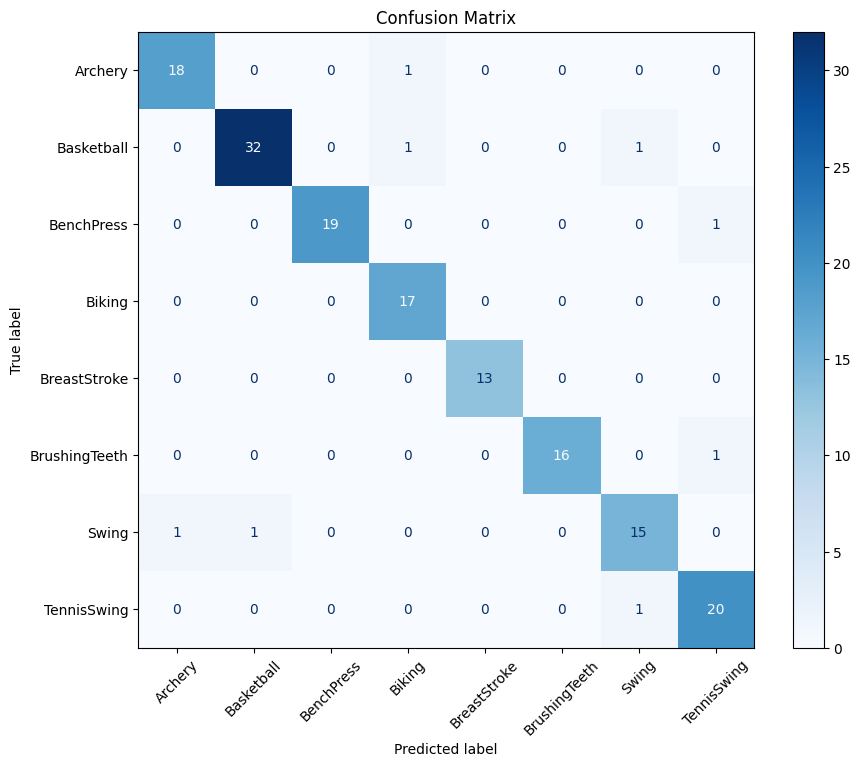

In [77]:
all_labels, all_preds = model.get_predictions_and_labels(test_loader)

cm = confusion_matrix(all_labels, all_preds)

idx_to_class = {i: c for c, i in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d", ax=ax)
ax.set_title("Confusion Matrix")
plt.show()

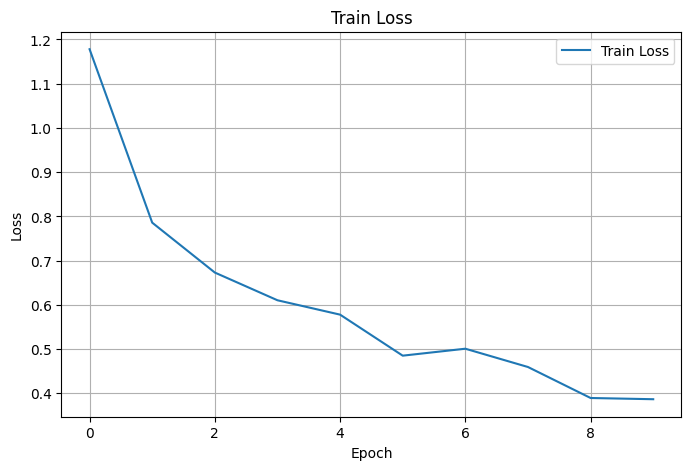

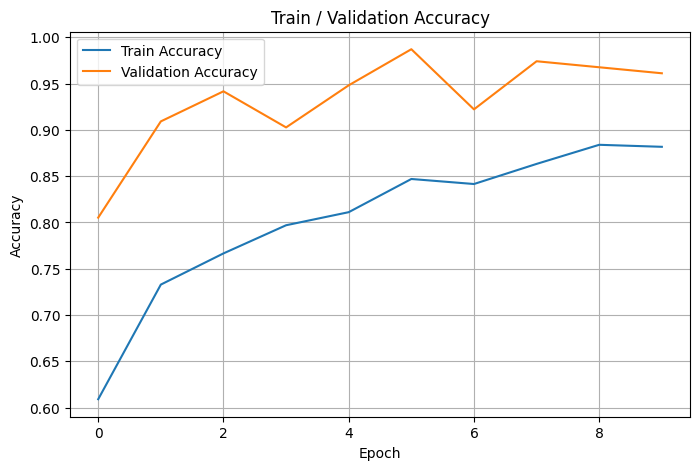

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(model.train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(model.train_accuracies, label="Train Accuracy")
if len(model.val_accuracies) > 0:
    plt.plot(model.val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 5. Створення та тренування моделі CNN-LSTM. Оцінка моделі.

In [80]:
lstm_model = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=LR,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model.fit(train_loader, val_loader, epochs=EPOCHS)

test_acc = lstm_model.evaluate(test_loader)
print("Test accuracy:", test_acc)

preds = lstm_model.predict(test_loader)
print(preds[:10])

Epoch 1/10 | Train loss: 1.4974 | Train acc: 0.4875
Epoch 1/10 | Val acc: 0.7662
Epoch 2/10 | Train loss: 1.0208 | Train acc: 0.6623
Epoch 2/10 | Val acc: 0.9026
Epoch 3/10 | Train loss: 0.8401 | Train acc: 0.7264
Epoch 3/10 | Val acc: 0.8961
Epoch 4/10 | Train loss: 0.7273 | Train acc: 0.7622
Epoch 4/10 | Val acc: 0.9156
Epoch 5/10 | Train loss: 0.6522 | Train acc: 0.7883
Epoch 5/10 | Val acc: 0.9416
Epoch 6/10 | Train loss: 0.6438 | Train acc: 0.7926
Epoch 6/10 | Val acc: 0.8896
Epoch 7/10 | Train loss: 0.6835 | Train acc: 0.7709
Epoch 7/10 | Val acc: 0.9545
Epoch 8/10 | Train loss: 0.5268 | Train acc: 0.8274
Epoch 8/10 | Val acc: 0.9416
Epoch 9/10 | Train loss: 0.5609 | Train acc: 0.8143
Epoch 9/10 | Val acc: 0.9870
Epoch 10/10 | Train loss: 0.5340 | Train acc: 0.8208
Epoch 10/10 | Val acc: 0.9610
Test accuracy: 0.9430379746835443
[6, 6, 6, 6, 6, 1, 6, 6, 6, 6]


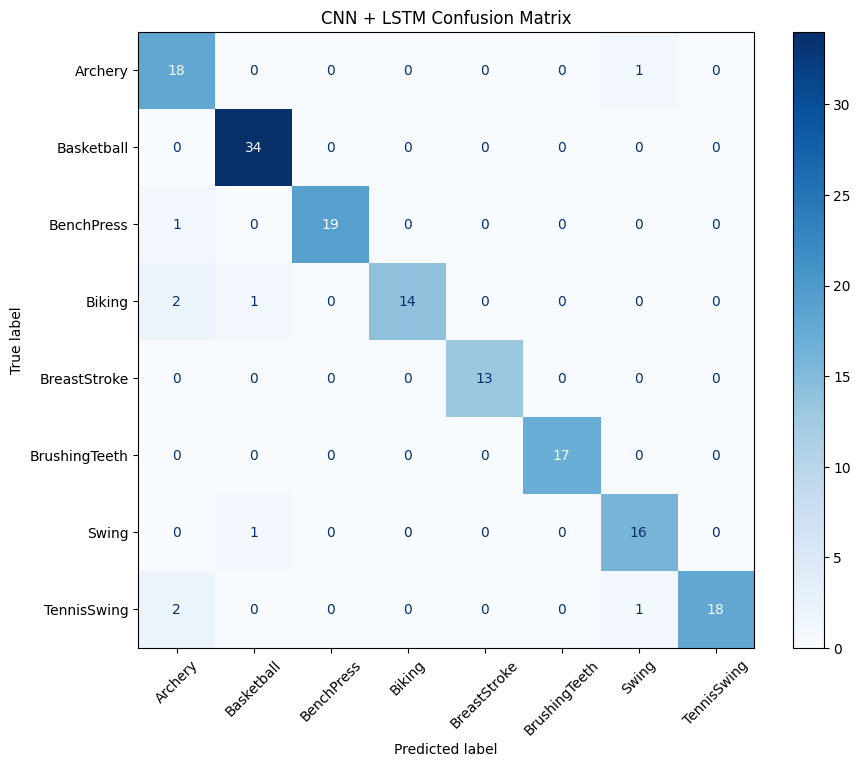

In [81]:
all_labels, all_preds = lstm_model.get_predictions_and_labels(test_loader)

cm = confusion_matrix(all_labels, all_preds)

idx_to_class = {i: c for c, i in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d", ax=ax)
ax.set_title("CNN + LSTM Confusion Matrix")
plt.show()

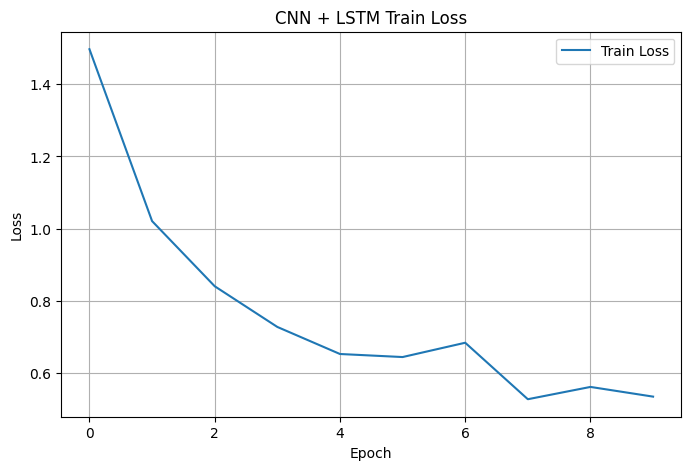

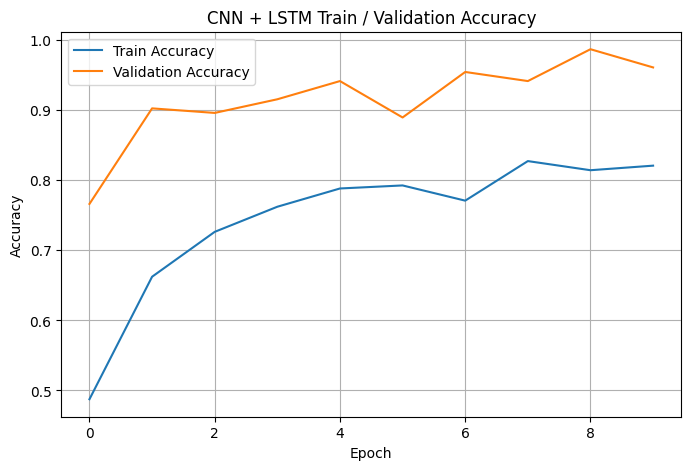

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(lstm_model.train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + LSTM Train Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lstm_model.train_accuracies, label="Train Accuracy")
if len(lstm_model.val_accuracies) > 0:
    plt.plot(lstm_model.val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + LSTM Train / Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()